In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import netCDF4 as nc
import xarray as xr
import datetime as dt
from salishsea_tools import evaltools as et, viz_tools, places
import gsw 
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import matplotlib.dates as mdates
import cmocean as cmo
import scipy.interpolate as sinterp
import math
from scipy import io
import pickle
import cmocean
from salishsea_tools import Keegan_eval_tools as ket
import json
from collections import OrderedDict
from matplotlib.colors import LogNorm
import arrow
import glob
import datetime
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib.dates import HourLocator, MonthLocator, YearLocator

fs=16
mpl.rc('xtick', labelsize=fs)
mpl.rc('ytick', labelsize=fs)
mpl.rc('legend', fontsize=fs)
mpl.rc('axes', titlesize=fs)
mpl.rc('axes', labelsize=fs)
mpl.rc('figure', titlesize=fs)
mpl.rc('font', size=fs)
mpl.rc('font', family='sans-serif', weight='normal', style='normal')

import warnings
#warnings.filterwarnings('ignore')
from IPython.display import Markdown, display

%matplotlib inline

In [2]:
JdF = [300,365, 50, 100]

In [3]:
with nc.Dataset('/ocean/ksuchy/MOAD/NEMO-forcing/grid/mesh_mask202108.nc') as mesh:
    e3t = np.copy(mesh.variables['e3t_0'][0,0:24,:,:])
    tmask=np.copy(mesh.variables['tmask'][0,0:24,:,:])

    # Load variables
    e3t  = mesh.variables['e3t_0'][0, 0:24, :, :]
    tmask = mesh.variables['tmask'][0, 0:24, :, :]

    e1t = mesh.variables['e1t'][:, :]
    e2t = mesh.variables['e2t'][:, :]

    # Expand e1t and e2t to match 3D vertical shape
    e1t_3d = np.broadcast_to(e1t, e3t.shape)
    e2t_3d = np.broadcast_to(e2t, e3t.shape)

    # Compute volume
    volume = tmask * e1t_3d * e2t_3d * e3t

    # Slice box
    denominator = np.nansum(volume[:, 300:365, 50:100])

In [4]:
yearList = [2014, 2015, 2016, 2017]
data = 'month-avg.202111'
file = 'biol'

# months April (4) to September (9)
months = [5]

# Collect all files for the desired years and months
files = []
for year in yearList:
    for month in months:
        matched = glob.glob(f'/results2/SalishSea/{data}/SalishSeaCast_1m_{file}_T_*{year}*{month:02d}01_*{year}*{month:02d}??.nc')
        files.extend(matched)

print(f"Found {len(files)} files")

# Now open them with xarray
ds = xr.open_mfdataset(files, combine='by_coords')

# Extract the variable
NO3 = ds['nitrate']

# Optional: check the shape
print(NO3.shape)

Found 4 files
(4, 40, 898, 398)


In [5]:
MHW_NO3_mean = np.mean(NO3,axis=0)

In [6]:
np.shape(MHW_NO3_mean)

(40, 898, 398)

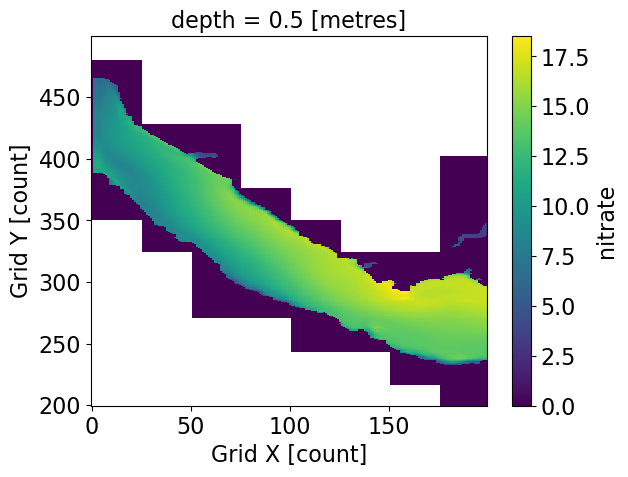

In [7]:
MHW_NO3_mean[0, 200:500, 0:200].plot();

In [8]:
MHW_numerator=np.nansum(
    np.array(MHW_NO3_mean[0:24, 300:365, 50:100]) * np.array(volume[0:24, 300:365, 50:100]))

In [9]:
MHW_average_NO3 = MHW_numerator/denominator
MHW_average_NO3

17.983150983837376

## Dataset for climatology

In [10]:
clim=nc.Dataset('/results2/SalishSea/month-avg.202111/SalishSeaCast_month_climatology_biol_T_20070101_20231231.nc')

In [11]:
clim.variables.keys()

dict_keys(['nitrate', 'ammonium', 'silicon', 'diatoms', 'flagellates', 'microzooplankton', 'dissolved_organic_nitrogen', 'particulate_organic_nitrogen', 'biogenic_silicon', 'mesozooplankton', 'depth', 'gridY', 'gridX', 'month'])

In [12]:

months_may = slice(4,5)  # selects only May 

Clim_NO3_mean = np.mean(clim['nitrate'][months_may] ,axis=0)


In [13]:
np.shape(Clim_NO3_mean)

(40, 898, 398)

In [14]:
Clim_numerator=np.nansum(
    np.array(Clim_NO3_mean[0:24, 300:365, 50:100]) * np.array(volume[0:24, 300:365, 50:100]))

In [15]:
Clim_average_NO3 = Clim_numerator/denominator
Clim_average_NO3

20.08816831727188

In [16]:
MHW_average_NO3 - Clim_average_NO3

-2.1050173334345033